<a href="https://colab.research.google.com/github/zarinhadika/CreditCardFraudDetection/blob/main/Dataset3Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# Nested CV Credit Card Fraud Detection (Leakage-Safe)
# ============================================================
!pip install catboost
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, average_precision_score
)

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ============================================================
# 1. Data Loading & Robust Cleaning
# ============================================================

df = pd.read_csv("/content/fraud_data.csv")
df.columns = df.columns.str.strip()

# Robust is_fraud fix
df["is_fraud"] = pd.to_numeric(df["is_fraud"], errors="coerce")

if df["is_fraud"].isna().all():
    df["is_fraud"] = df["is_fraud"].astype(str).str[0]
    df["is_fraud"] = pd.to_numeric(df["is_fraud"], errors="coerce")

df = df[df["is_fraud"].isin([0, 1])]
df["is_fraud"] = df["is_fraud"].astype(int)

# Datetime parsing
df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], format="%d-%m-%Y %H:%M")
df["dob"] = pd.to_datetime(df["dob"], dayfirst=True)

# ============================================================
# 2. Missing Value Handling (Audit + Impute)
# ============================================================

print("\n=== Missing Value Audit ===")
na_report = df.isna().sum()
na_report = na_report[na_report > 0]
for col in na_report.index:
    pct = 100 * na_report[col] / len(df)
    print(f"{col:25s} | {na_report[col]:5d} | {pct:6.2f}%")

for col in df.columns:
    n_missing = df[col].isna().sum()
    if n_missing == 0:
        continue

    if np.issubdtype(df[col].dtype, np.number):
        median = df[col].median()
        df[col].fillna(median, inplace=True)
        print(f"Imputed {col} with MEDIAN ({n_missing} values)")

    elif np.issubdtype(df[col].dtype, np.datetime64):
        df[col].fillna(method="ffill", inplace=True)
        df[col].fillna(method="bfill", inplace=True)
        print(f"Imputed {col} with FFILL/BFILL ({n_missing} values)")

    else:
        mode = df[col].mode()
        fill = mode[0] if not mode.empty else "missing"
        df[col].fillna(fill, inplace=True)
        print(f"Imputed {col} with MODE/'missing' ({n_missing} values)")

print("Total remaining NaNs:", df.isna().sum().sum())

# ============================================================
# 3. Row-wise Feature Engineering
# ============================================================

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["tx_hour"] = df["trans_date_trans_time"].dt.hour
df["tx_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
df["tx_month"] = df["trans_date_trans_time"].dt.month
df["tx_is_weekend"] = df["tx_dayofweek"].isin([5,6]).astype(int)
df["tx_is_night"] = ((df["tx_hour"] < 6) | (df["tx_hour"] >= 22)).astype(int)

df["age"] = (
    (df["trans_date_trans_time"] - df["dob"]).dt.days / 365
).clip(18, 100)

df["distance_km"] = haversine(
    df["lat"], df["long"], df["merch_lat"], df["merch_long"]
)

df["log_amt"] = np.log1p(df["amt"])
df["amt_per_pop"] = df["amt"] / df["city_pop"]

def hour_bucket(h):
    if 6 <= h < 12: return "morning"
    if 12 <= h < 18: return "afternoon"
    if 18 <= h < 22: return "evening"
    return "night"

df["hour_bucket"] = df["tx_hour"].apply(hour_bucket)

# ============================================================
# Feature Selection
# ============================================================

target = "is_fraud"

categorical_cols = ["category", "state", "hour_bucket"]

numeric_cols = [
    "amt","city_pop","lat","long","merch_lat","merch_long",
    "tx_hour","tx_dayofweek","tx_month",
    "tx_is_weekend","tx_is_night","age",
    "distance_km","log_amt","amt_per_pop"
]

X = df[categorical_cols + numeric_cols]
y = df[target]

# ============================================================
# Preprocessing builders
# ============================================================

def build_ohe_pipeline(model):
    pre = ColumnTransformer([
        ("num", RobustScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols)
    ])
    return Pipeline([("pre", pre), ("clf", model)])

def scale_numeric_only(X_train, X_val):
    scaler = RobustScaler()
    X_train_num = scaler.fit_transform(X_train[numeric_cols])
    X_val_num = scaler.transform(X_val[numeric_cols])

    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()

    X_train_scaled[numeric_cols] = X_train_num
    X_val_scaled[numeric_cols] = X_val_num

    return X_train_scaled, X_val_scaled

# ============================================================
# Model grids
# ============================================================

n_pos = y.sum()
n_neg = len(y) - n_pos
scale_pos = n_neg / n_pos

models = {
    "LogReg(OHE)": (
        LogisticRegression(class_weight="balanced", solver="saga", max_iter=1000, random_state=42),
        {"clf__C": [0.1, 1.0, 10.0]}
    ),
    "RandomForest(OHE)": (
        RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=42),
        {"clf__n_estimators": [400, 800],
         "clf__max_depth": [6, 10, None]}
    ),
    "LightGBM(OHE)": (
        LGBMClassifier(class_weight="balanced", verbose=-1, random_state=42),
        {"clf__n_estimators": [300, 600],
         "clf__max_depth": [5, 8],
         "clf__learning_rate": [0.05, 0.1]}
    ),
    "XGBoost(OHE)": (
        XGBClassifier(
            eval_metric="logloss",
            scale_pos_weight=scale_pos,
            verbosity=0,
            n_jobs=-1,
            random_state=42
        ),
        {"clf__n_estimators": [300, 600],
         "clf__max_depth": [4, 6],
         "clf__learning_rate": [0.05, 0.1]}
    ),
    "CatBoost": (
        CatBoostClassifier(
            auto_class_weights="Balanced",
            verbose=0,
            random_seed=42
        ),
        {"iterations": [300, 600],
         "depth": [4, 6],
         "learning_rate": [0.05, 0.1]}
    )
}

# ============================================================
# 6. Nested Cross Validation
# ============================================================

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

results = []

for model_name, (base_model, param_grid) in models.items():
    print(f"\n================ {model_name} ================\n")

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # ---------------- Inner HP tuning ----------------
        best_score = -1
        best_params = None

        for params in ParameterGrid(param_grid):
            inner_scores = []

            for itrain, ival in inner_cv.split(X_train, y_train):
                Xi_tr, Xi_val = X_train.iloc[itrain], X_train.iloc[ival]
                yi_tr, yi_val = y_train.iloc[itrain], y_train.iloc[ival]

                if "OHE" in model_name:
                    pipe = build_ohe_pipeline(base_model)
                    pipe.set_params(**params)
                    pipe.fit(Xi_tr, yi_tr)
                    probs = pipe.predict_proba(Xi_val)[:,1]

                else:
                    Xi_tr_s, Xi_val_s = scale_numeric_only(Xi_tr, Xi_val)
                    model = CatBoostClassifier(**params,
                        auto_class_weights="Balanced",
                        verbose=0,
                        random_seed=42
                    )
                    model.fit(
                        Xi_tr_s, yi_tr,
                        cat_features=categorical_cols
                    )
                    probs = model.predict_proba(Xi_val_s)[:,1]

                inner_scores.append(roc_auc_score(yi_val, probs))

            mean_score = np.mean(inner_scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = params

        # ---------------- Threshold tuning ----------------
        thresholds = []
        for itrain, ival in inner_cv.split(X_train, y_train):
            Xi_tr, Xi_val = X_train.iloc[itrain], X_train.iloc[ival]
            yi_tr, yi_val = y_train.iloc[itrain], y_train.iloc[ival]

            if "OHE" in model_name:
                pipe = build_ohe_pipeline(base_model)
                pipe.set_params(**best_params)
                pipe.fit(Xi_tr, yi_tr)
                probs = pipe.predict_proba(Xi_val)[:,1]
            else:
                Xi_tr_s, Xi_val_s = scale_numeric_only(Xi_tr, Xi_val)
                model = CatBoostClassifier(**best_params,
                    auto_class_weights="Balanced",
                    verbose=0,
                    random_seed=42
                )
                model.fit(Xi_tr_s, yi_tr, cat_features=categorical_cols)
                probs = model.predict_proba(Xi_val_s)[:,1]

            f1s = [f1_score(yi_val, probs >= t) for t in np.linspace(0.1,0.9,40)]
            thresholds.append(np.linspace(0.1,0.9,40)[np.argmax(f1s)])

        chosen_threshold = np.mean(thresholds)

        # ---------------- Outer evaluation ----------------
        if "OHE" in model_name:
            pipe = build_ohe_pipeline(base_model)
            pipe.set_params(**best_params)
            pipe.fit(X_train, y_train)
            probs = pipe.predict_proba(X_test)[:,1]
        else:
            X_train_s, X_test_s = scale_numeric_only(X_train, X_test)
            model = CatBoostClassifier(**best_params,
                auto_class_weights="Balanced",
                verbose=0,
                random_seed=42
            )
            model.fit(X_train_s, y_train, cat_features=categorical_cols)
            probs = model.predict_proba(X_test_s)[:,1]

        preds = (probs >= chosen_threshold).astype(int)

        row = {
            "model": model_name,
            "fold": fold,
            "chosen_threshold": chosen_threshold,
            "best_inner_score": best_score,
            "best_params": best_params,
            "accuracy": accuracy_score(y_test, preds),
            "f1": f1_score(y_test, preds, zero_division=0),
            "precision": precision_score(y_test, preds, zero_division=0),
            "recall": recall_score(y_test, preds, zero_division=0),
            "roc_auc": roc_auc_score(y_test, probs),
            "pr_auc": average_precision_score(y_test, probs),
        }

        results.append(row)

# ============================================================
# 8. Output Tables
# ============================================================

df_results = pd.DataFrame(results)
df_summary = df_results.drop(columns=['best_params']).groupby("model").agg(["mean","std"])

df_results.to_csv("nested_cv_fold_results.csv", index=False)
df_summary.to_csv("nested_cv_summary.csv")

print("\nSaved:")
print(" - nested_cv_fold_results.csv")
print(" - nested_cv_summary.csv")


=== Missing Value Audit ===
Total remaining NaNs: 0

================ LogReg(OHE) ================


================ RandomForest(OHE) ================


================ LightGBM(OHE) ================


================ XGBoost(OHE) ================


================ CatBoost ================


Saved:
 - nested_cv_fold_results.csv
 - nested_cv_summary.csv



SECTION 9.1 — SHAP Interaction Heatmap

  ── Fold 1/5: training model for SHAP …


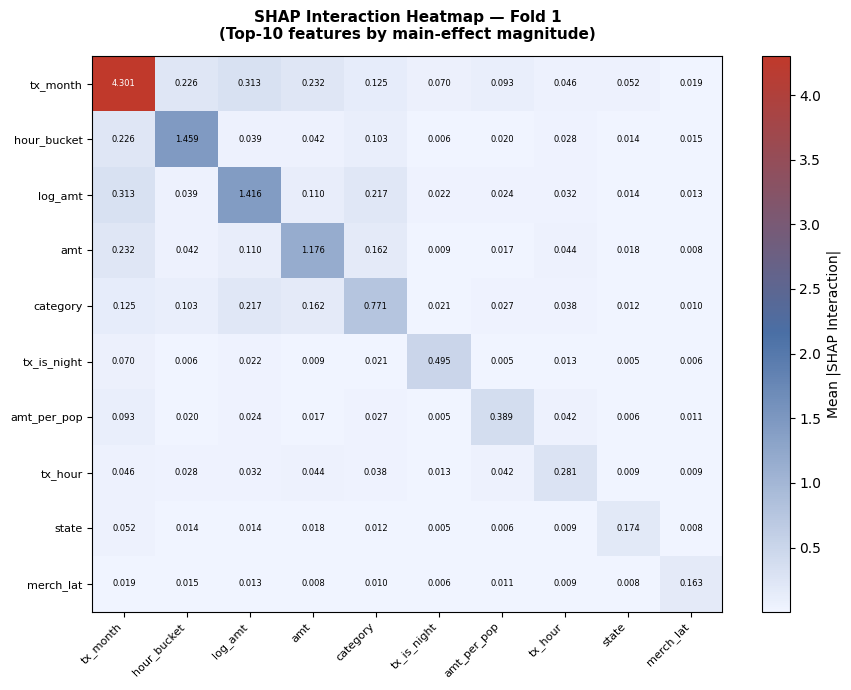


  Top-20 Interaction Pairs — Fold 1
  feature_A   feature_B  mean_abs_interaction
   tx_month     log_amt              0.313240
        amt    tx_month              0.231547
hour_bucket    tx_month              0.226332
   category     log_amt              0.216663
   category         amt              0.161926
   category    tx_month              0.124911
   city_pop    tx_month              0.123432
        amt     log_amt              0.109569
   category hour_bucket              0.102634
   tx_month amt_per_pop              0.092870
   tx_month tx_is_night              0.070261
    tx_hour         age              0.060306
      state    tx_month              0.052169
   tx_month         age              0.048722
    tx_hour    tx_month              0.046106
       long    tx_month              0.045793
       long  merch_long              0.044347
        amt     tx_hour              0.044157
hour_bucket         amt              0.042138
    tx_hour amt_per_pop              0.0418

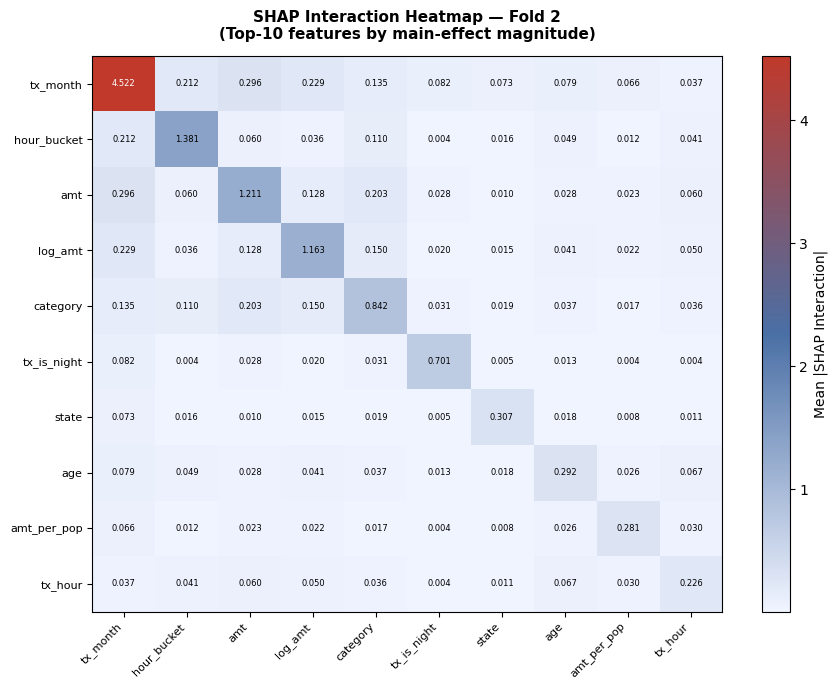


  Top-20 Interaction Pairs — Fold 2
  feature_A   feature_B  mean_abs_interaction
        amt    tx_month              0.295669
   tx_month     log_amt              0.229071
hour_bucket    tx_month              0.212109
   category         amt              0.203343
   category     log_amt              0.150058
   category    tx_month              0.134665
   city_pop    tx_month              0.128372
        amt     log_amt              0.128100
   category hour_bucket              0.109998
   tx_month tx_is_night              0.081726
   tx_month         age              0.079036
      state    tx_month              0.073318
    tx_hour         age              0.067345
   tx_month amt_per_pop              0.065631
hour_bucket         amt              0.059796
        amt     tx_hour              0.059654
   city_pop         age              0.051724
    tx_hour     log_amt              0.050470
hour_bucket         age              0.048726
  merch_lat         age              0.0462

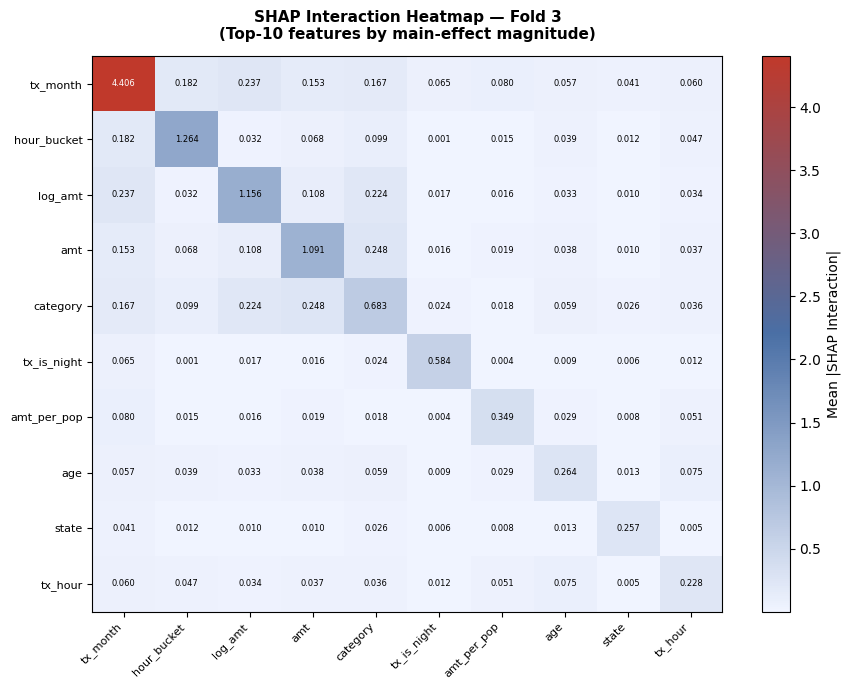


  Top-20 Interaction Pairs — Fold 3
  feature_A   feature_B  mean_abs_interaction
   category         amt              0.248027
   tx_month     log_amt              0.236693
   category     log_amt              0.224030
hour_bucket    tx_month              0.181735
   category    tx_month              0.166573
        amt    tx_month              0.153116
   city_pop    tx_month              0.120808
        amt     log_amt              0.108271
   category hour_bucket              0.098662
   tx_month amt_per_pop              0.080239
    tx_hour         age              0.074783
hour_bucket         amt              0.068286
   tx_month tx_is_night              0.064915
    tx_hour    tx_month              0.059740
   category         age              0.058640
   tx_month         age              0.057280
        lat         age              0.053866
   city_pop         age              0.051964
    tx_hour amt_per_pop              0.050693
        lat    tx_month              0.0477

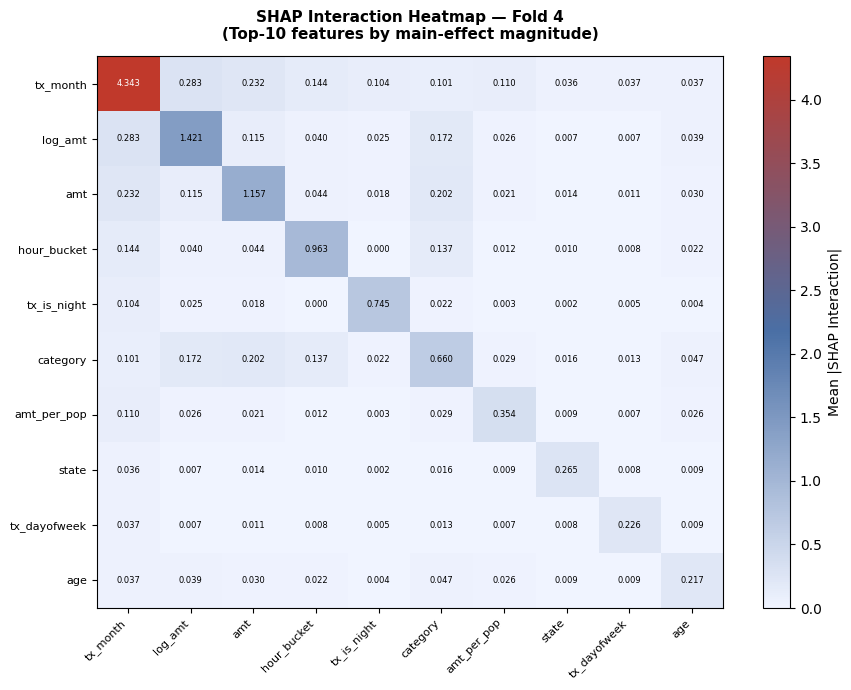


  Top-20 Interaction Pairs — Fold 4
  feature_A   feature_B  mean_abs_interaction
   tx_month     log_amt              0.283483
        amt    tx_month              0.231929
   category         amt              0.202426
   category     log_amt              0.171960
hour_bucket    tx_month              0.144077
   category hour_bucket              0.136614
   city_pop    tx_month              0.116888
        amt     log_amt              0.115194
   tx_month amt_per_pop              0.109855
   tx_month tx_is_night              0.104338
   category    tx_month              0.101288
    tx_hour         age              0.075074
   category     tx_hour              0.051972
   category         age              0.046892
    tx_hour     log_amt              0.045309
hour_bucket         amt              0.044496
        lat         age              0.042089
hour_bucket     log_amt              0.039656
        age     log_amt              0.038867
        amt     tx_hour              0.0378

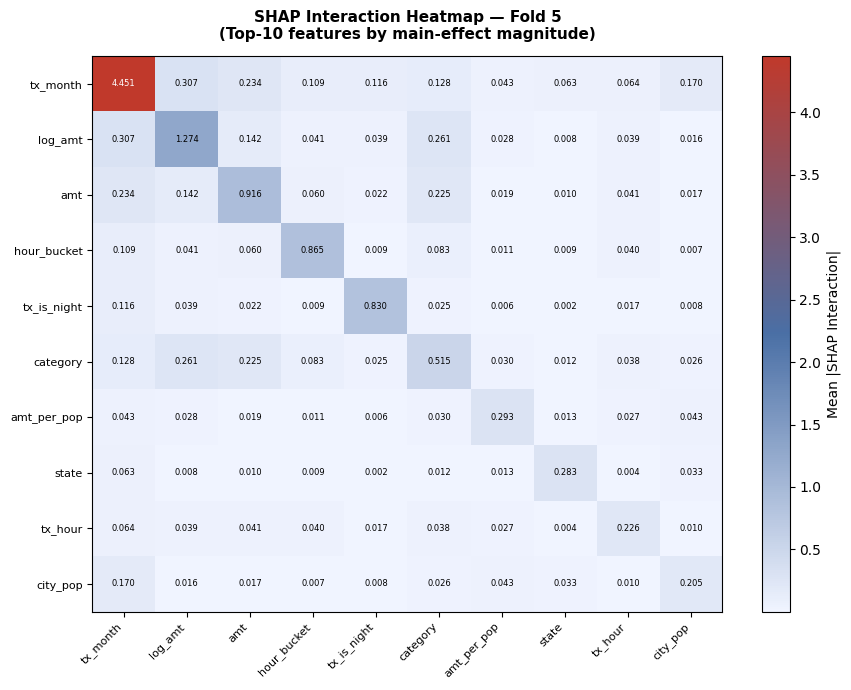


  Top-20 Interaction Pairs — Fold 5
  feature_A   feature_B  mean_abs_interaction
   tx_month     log_amt              0.306604
   category     log_amt              0.260668
        amt    tx_month              0.233629
   category         amt              0.225409
   city_pop    tx_month              0.170211
        amt     log_amt              0.142132
   category    tx_month              0.127538
   tx_month tx_is_night              0.116005
hour_bucket    tx_month              0.109003
   category hour_bucket              0.082916
   city_pop         age              0.064116
    tx_hour    tx_month              0.063930
      state    tx_month              0.062725
hour_bucket         amt              0.059606
    tx_hour         age              0.048341
   city_pop amt_per_pop              0.042887
   tx_month amt_per_pop              0.042823
        amt     tx_hour              0.040575
hour_bucket     log_amt              0.040562
hour_bucket     tx_hour              0.0397

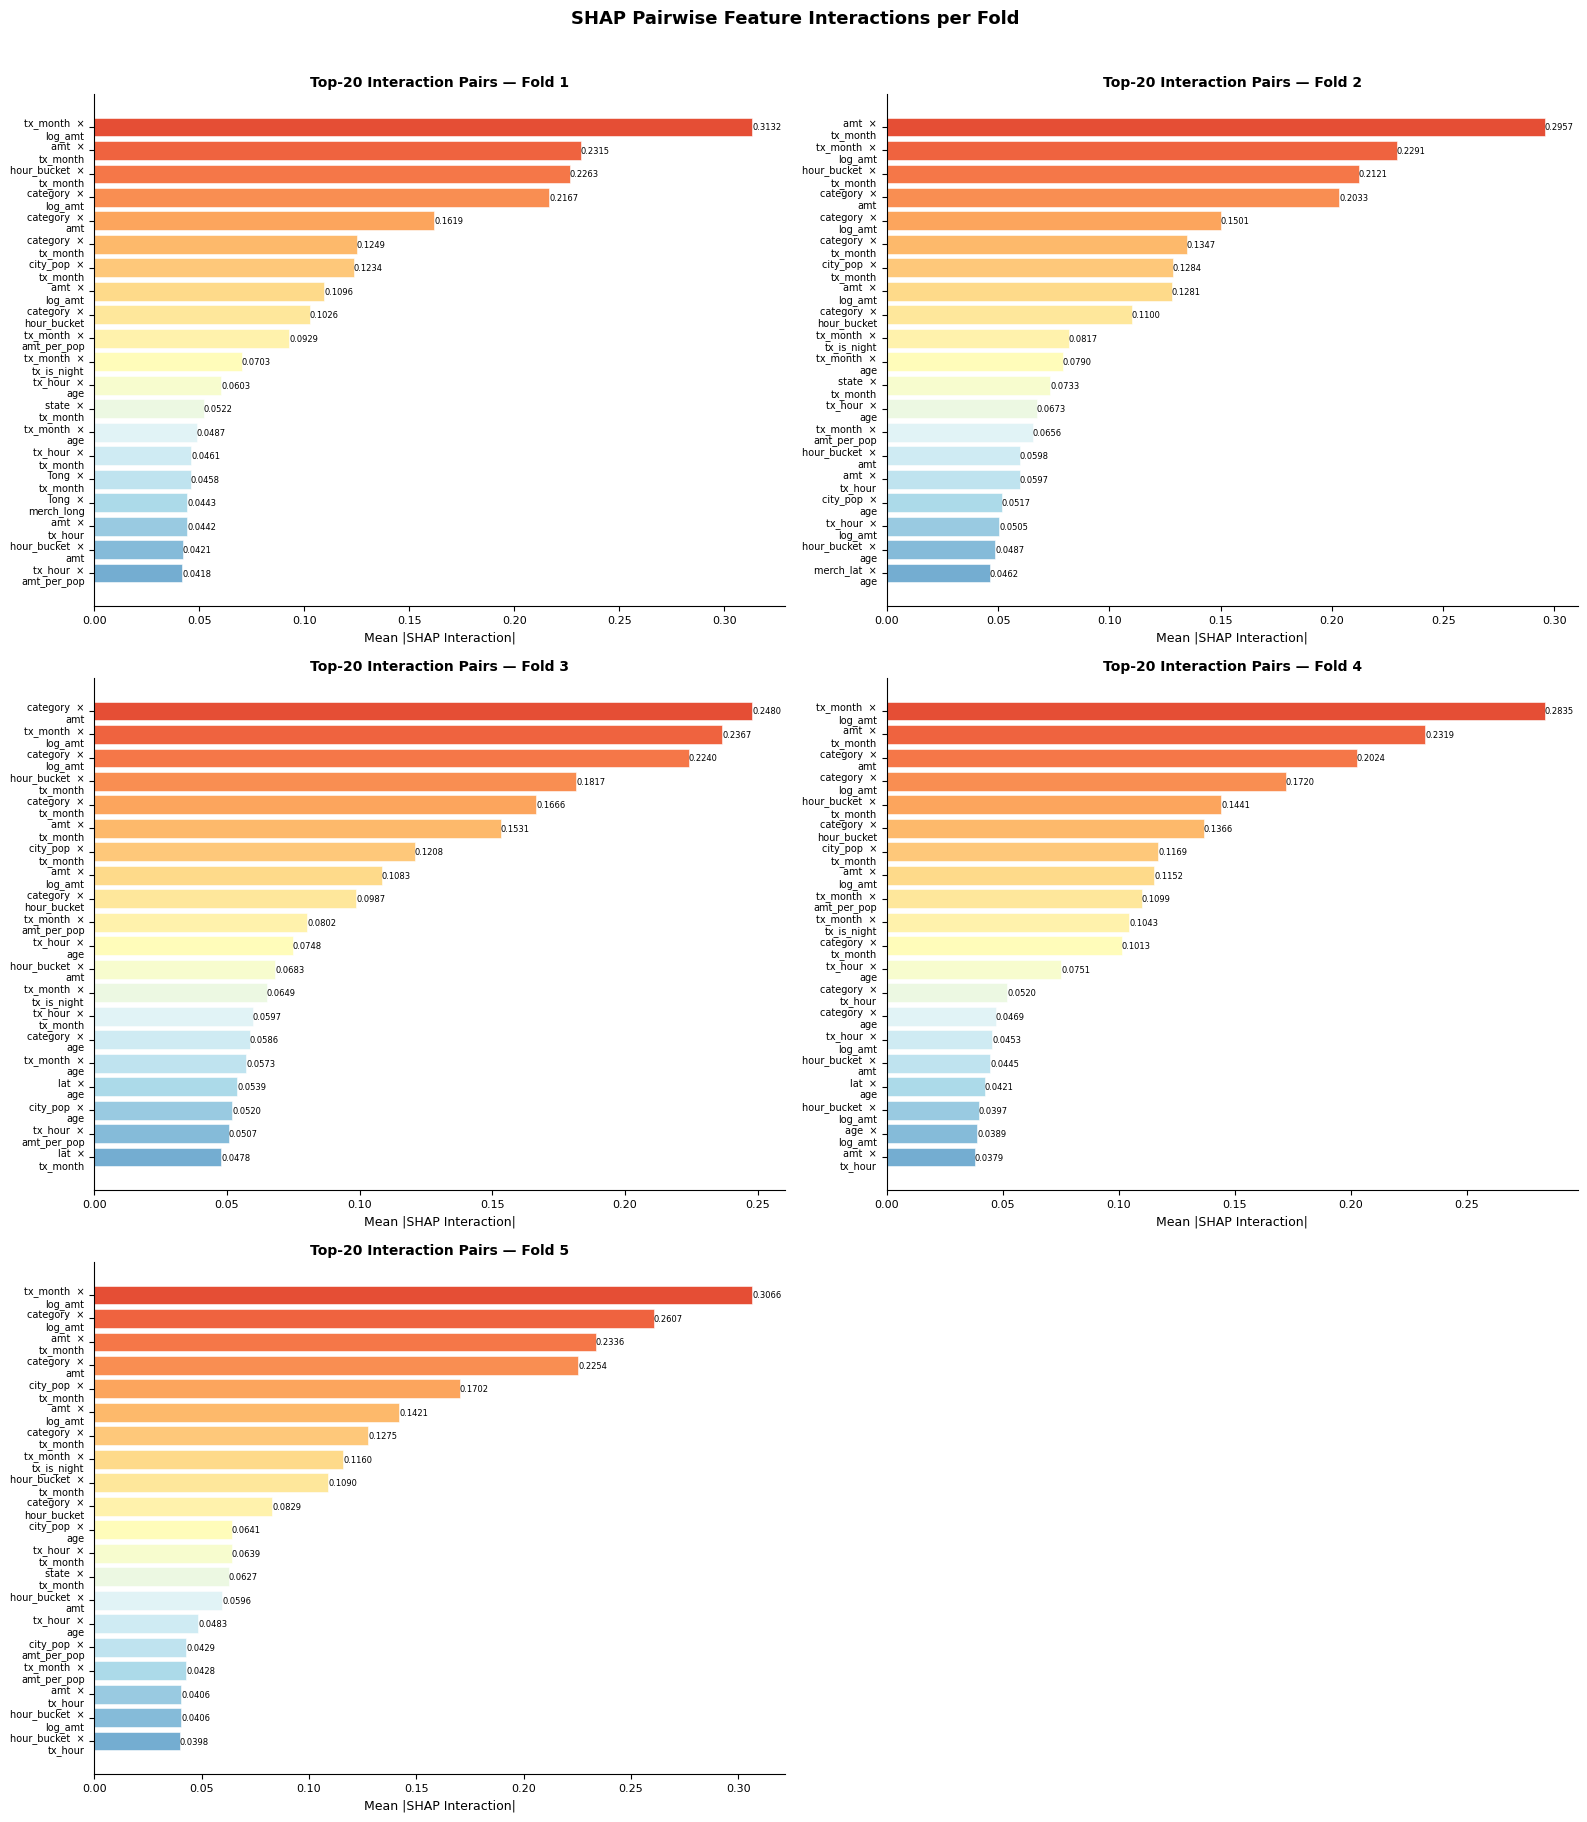


SECTION 9.3 — Global Interaction Summary

Global Interaction Summary (top 30 pairs):
  feature_A   feature_B     mean      std  count
   tx_month     log_amt 0.273818 0.039061      5
        amt    tx_month 0.229178 0.050595      5
   category         amt 0.208226 0.031940      5
   category     log_amt 0.204675 0.043894      5
hour_bucket    tx_month 0.174651 0.048396      5
   city_pop    tx_month 0.131942 0.021796      5
   category    tx_month 0.130995 0.023509      5
        amt     log_amt 0.120653 0.014342      5
   category hour_bucket 0.106165 0.019692      5
   tx_month tx_is_night 0.087449 0.022003      5
   tx_month amt_per_pop 0.078284 0.025646      5
    tx_hour         age 0.065170 0.011204      5
      state    tx_month 0.062737 0.010574      3
   tx_month         age 0.061679 0.015629      3
    tx_hour    tx_month 0.056592 0.009320      3
   city_pop         age 0.055935 0.007086      3
hour_bucket         amt 0.054864 0.011140      5
   category         age 0.052766

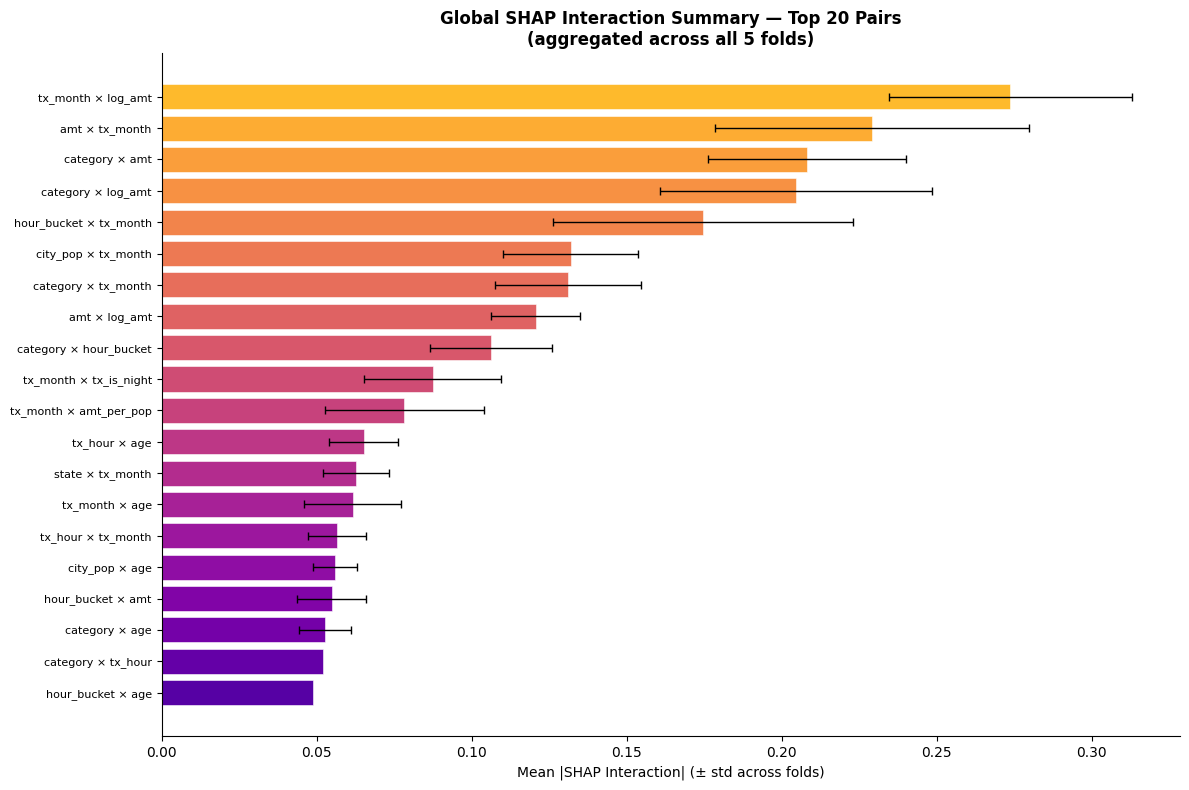

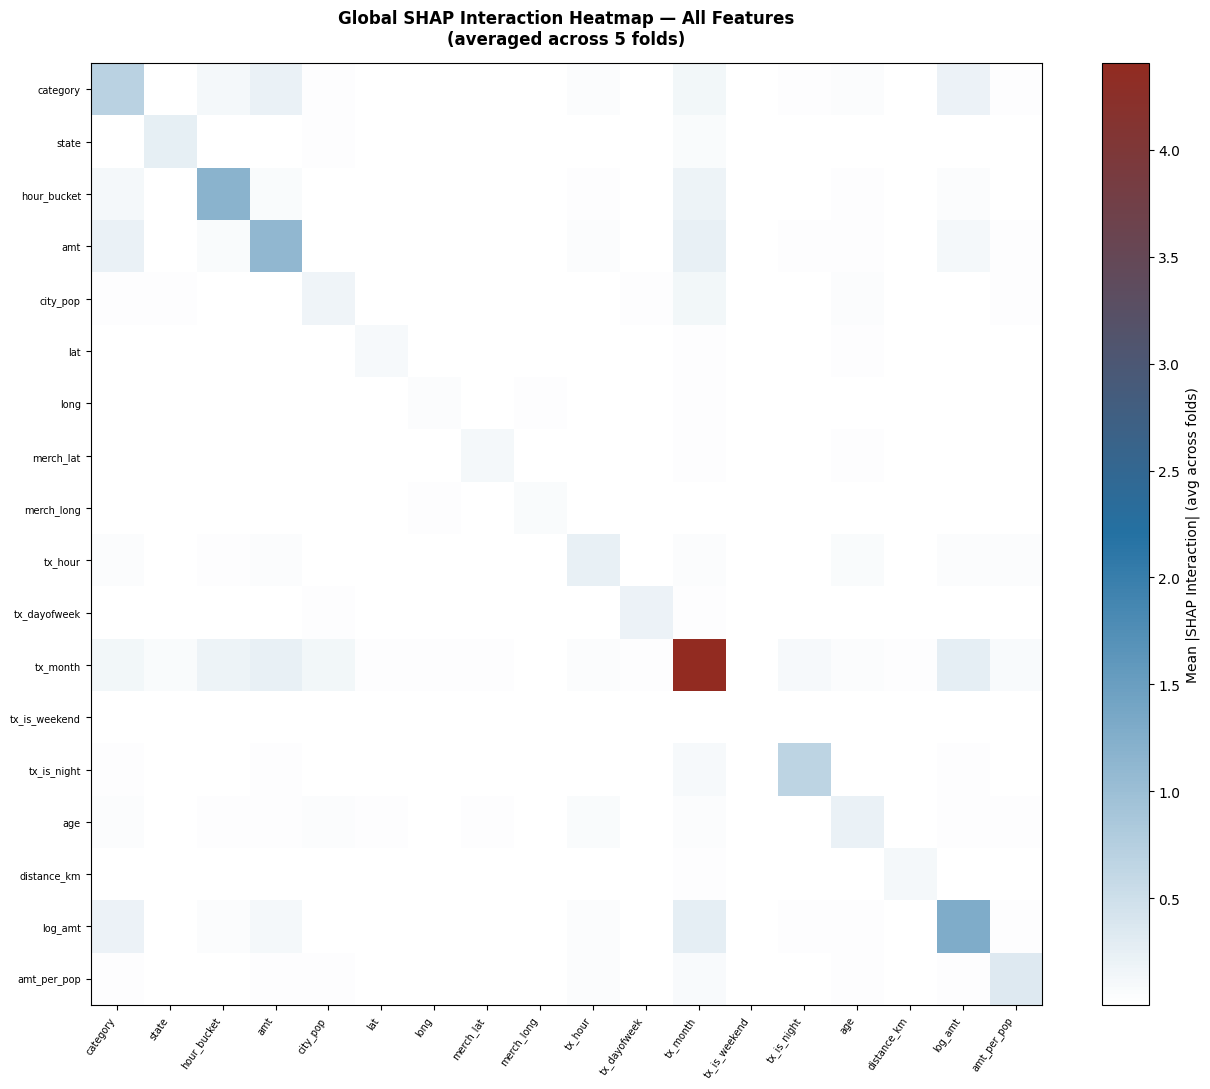


SECTION 9.4 — Counterfactual Explanations (DiCE)

  Training final CatBoost on full dataset …
  Final model trained.

  Selected fraud sample index : 1775
  Original fraud probability  : 0.8593

  Generating counterfactuals (target class → 0) …


100%|██████████| 1/1 [00:00<00:00,  3.03it/s]


  Original fraud instance:
         category state hour_bucket       amt  city_pop       lat      long  merch_lat  merch_long   tx_hour  tx_dayofweek  tx_month  tx_is_weekend  tx_is_night       age  distance_km   log_amt  amt_per_pop
1775  food_dining    CA       night  0.556477  0.275024 -0.118507 -0.613819  -0.172639   -0.627041 -0.923077          0.25  0.727273            0.0          1.0  0.088943    -0.254229  0.323137    -0.070233

  Counterfactual instances (toward non-fraud):
      category state hour_bucket       amt   city_pop       lat      long  merch_lat  merch_long   tx_hour  tx_dayofweek  tx_month  tx_is_weekend  tx_is_night       age  distance_km   log_amt  amt_per_pop  is_fraud
0  food_dining    CA       night  0.556477  12.465310 -0.118507 -0.613819  -0.172639   -0.627041 -0.923077          0.25  0.727273            0.0          1.0 -0.566616    -0.254229  0.323137    -0.070233         0
1  food_dining    CA       night  0.556477   0.275024 -0.118507 -0.613819  -0.17

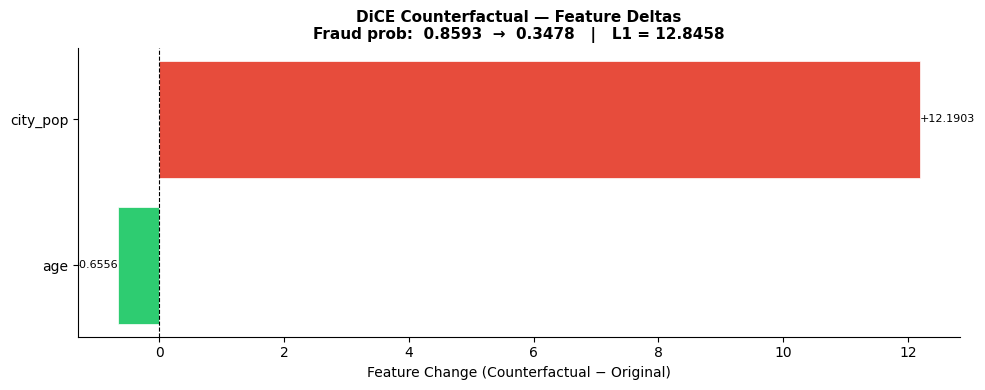


  Full numeric feature comparison (original vs best counterfactual):
               Original Counterfactual      Delta  Changed
amt            0.556477       0.556477        0.0    False
city_pop       0.275024       12.46531  12.190286     True
lat           -0.118507      -0.118507        0.0    False
long          -0.613819      -0.613819        0.0    False
merch_lat     -0.172639      -0.172639        0.0    False
merch_long    -0.627041      -0.627041        0.0    False
tx_hour       -0.923077      -0.923077        0.0    False
tx_dayofweek       0.25           0.25        0.0    False
tx_month       0.727273       0.727273        0.0    False
tx_is_weekend       0.0            0.0        0.0    False
tx_is_night         1.0            1.0        0.0    False
age            0.088943      -0.566616  -0.655559     True
distance_km   -0.254229      -0.254229        0.0    False
log_amt        0.323137       0.323137        0.0    False
amt_per_pop   -0.070233      -0.070233       

In [ ]:
# ============================================================
# SECTION 9: Advanced Explainability Analysis
# ============================================================
# Appends to existing nested CV pipeline.
# Requires: X, y, categorical_cols, numeric_cols (already defined)
# ============================================================

!pip install shap dice-ml --quiet

import shap
import dice_ml
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
import numpy as np
from collections import defaultdict
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import RobustScaler
from catboost import CatBoostClassifier, Pool

shap.initjs()

# ============================================================
# Utility: Scale only numeric columns (mirrors existing pipeline)
# ============================================================

def scale_numeric(X_train, X_test, num_cols):
    """Fit RobustScaler on train, transform both splits."""
    scaler = RobustScaler()
    X_tr = X_train.copy()
    X_te = X_test.copy()
    X_tr[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_te[num_cols] = scaler.transform(X_test[num_cols])
    return X_tr, X_te, scaler

# ============================================================
# Utility: Train CatBoost with best fixed params
# (Uses balanced class weights; cat features passed natively)
# ============================================================

CATBOOST_PARAMS = dict(
    iterations=600,
    depth=6,
    learning_rate=0.05,
    auto_class_weights="Balanced",
    verbose=0,
    random_seed=42,
)

def train_catboost(X_tr, y_tr, cat_cols):
    """Train a CatBoost model; returns fitted model."""
    model = CatBoostClassifier(**CATBOOST_PARAMS)
    model.fit(X_tr, y_tr, cat_features=cat_cols)
    return model

# ============================================================
# SECTION 9.1 — SHAP Interaction Heatmap (fold-wise)
# ============================================================

print("\n" + "="*60)
print("SECTION 9.1 — SHAP Interaction Heatmap")
print("="*60)

shap_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Accumulator: sum of mean |interaction| matrices across folds
interaction_accumulator = None
feature_names_global   = None
fold_interaction_dfs   = []          # store per-fold pair rankings

for fold_idx, (tr_idx, te_idx) in enumerate(shap_cv.split(X, y), 1):
    print(f"\n  ── Fold {fold_idx}/5: training model for SHAP …")

    X_tr_raw, X_te_raw = X.iloc[tr_idx], X.iloc[te_idx]
    y_tr,     y_te     = y.iloc[tr_idx], y.iloc[te_idx]

    # Scale numerics; cats stay as-is (CatBoost handles them)
    X_tr_s, X_te_s, _ = scale_numeric(X_tr_raw, X_te_raw, numeric_cols)

    model = train_catboost(X_tr_s, y_tr, categorical_cols)

    # ── SHAP interaction values (TreeExplainer)
    # Use a stratified subsample of the test set for speed
    sample_idx = (
        X_te_s
        .groupby(y_te, group_keys=False)
        .apply(lambda g: g.sample(min(len(g), 150), random_state=42))
        .index
    )
    X_sample = X_te_s.loc[sample_idx]
    y_sample = y_te.loc[sample_idx]

    explainer    = shap.TreeExplainer(model)
    # shap_interaction_values shape: (n_samples, n_features, n_features)
    interact_vals = explainer.shap_interaction_values(X_sample)

    feat_names = list(X_sample.columns)
    if feature_names_global is None:
        feature_names_global   = feat_names
        interaction_accumulator = np.zeros((len(feat_names), len(feat_names)))

    # Mean absolute interaction across samples → (n_features, n_features)
    mean_abs_interact = np.abs(interact_vals).mean(axis=0)
    interaction_accumulator += mean_abs_interact

    # ── Plot per-fold heatmap (top 10 features by diagonal SHAP)
    diag_importance = np.diag(mean_abs_interact)
    top10_idx       = np.argsort(diag_importance)[::-1][:10]
    top10_names     = [feat_names[i] for i in top10_idx]
    sub_matrix      = mean_abs_interact[np.ix_(top10_idx, top10_idx)]

    cmap = LinearSegmentedColormap.from_list(
        "fraud_heat", ["#f0f4ff", "#4a6fa5", "#c0392b"]
    )

    fig, ax = plt.subplots(figsize=(9, 7))
    im = ax.imshow(sub_matrix, cmap=cmap, aspect="auto")
    ax.set_xticks(range(10)); ax.set_xticklabels(top10_names, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(10)); ax.set_yticklabels(top10_names, fontsize=8)
    plt.colorbar(im, ax=ax, label="Mean |SHAP Interaction|")
    ax.set_title(
        f"SHAP Interaction Heatmap — Fold {fold_idx}\n(Top-10 features by main-effect magnitude)",
        fontsize=11, fontweight="bold", pad=12
    )
    # Annotate cells
    for r in range(10):
        for c in range(10):
            ax.text(c, r, f"{sub_matrix[r, c]:.3f}",
                    ha="center", va="center", fontsize=6,
                    color="white" if sub_matrix[r, c] > sub_matrix.max()*0.6 else "black")
    plt.tight_layout()
    plt.show()

    # ── Extract top-20 pairwise interactions for this fold
    n_feat = len(feat_names)
    pairs = []
    for i in range(n_feat):
        for j in range(i+1, n_feat):           # upper triangle only
            pairs.append({
                "feature_A": feat_names[i],
                "feature_B": feat_names[j],
                "mean_abs_interaction": mean_abs_interact[i, j],
                "fold": fold_idx,
            })

    fold_df = (
        pd.DataFrame(pairs)
        .sort_values("mean_abs_interaction", ascending=False)
        .head(20)
        .reset_index(drop=True)
    )
    fold_interaction_dfs.append(fold_df)


    print(f"\n  Top-20 Interaction Pairs — Fold {fold_idx}")
    print(fold_df[["feature_A","feature_B","mean_abs_interaction"]].to_string(index=False))


# ============================================================
# SECTION 9.2 — Top SHAP Interaction Pairs per Fold (bar charts)
# ============================================================

print("\n" + "="*60)
print("SECTION 9.2 — Top SHAP Interaction Pairs per Fold")
print("="*60)

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for fold_idx, fold_df in enumerate(fold_interaction_dfs, 1):
    ax = axes[fold_idx - 1]
    pair_labels = fold_df.apply(
        lambda r: f"{r['feature_A']}  ×\n{r['feature_B']}", axis=1
    )
    colors = plt.cm.RdYlBu_r(
        np.linspace(0.2, 0.85, len(fold_df))
    )
    bars = ax.barh(pair_labels[::-1], fold_df["mean_abs_interaction"][::-1],
                   color=colors, edgecolor="white", linewidth=0.4)
    ax.set_xlabel("Mean |SHAP Interaction|", fontsize=9)
    ax.set_title(f"Top-20 Interaction Pairs — Fold {fold_idx}",
                 fontsize=10, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=8)
    # Value labels
    for bar, val in zip(bars, fold_df["mean_abs_interaction"][::-1]):
        ax.text(bar.get_width() + 1e-5, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=6)
    ax.spines[["top","right"]].set_visible(False)

# Hide unused subplot (6th panel)
axes[-1].set_visible(False)
plt.suptitle("SHAP Pairwise Feature Interactions per Fold",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 9.3 — Global Interaction Summary (across all folds)
# ============================================================

print("\n" + "="*60)
print("SECTION 9.3 — Global Interaction Summary")
print("="*60)

# Stack all fold DataFrames and aggregate
all_pairs_df = pd.concat(fold_interaction_dfs, ignore_index=True)

global_summary = (
    all_pairs_df
    .groupby(["feature_A", "feature_B"])["mean_abs_interaction"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
    .sort_values("mean", ascending=False)
    .reset_index(drop=True)
)

print("\nGlobal Interaction Summary (top 30 pairs):")
print(global_summary.head(30).to_string(index=False))

# ── Global summary bar chart (top 20)
top20_global = global_summary.head(20).copy()
pair_labels_g = top20_global.apply(
    lambda r: f"{r['feature_A']} × {r['feature_B']}", axis=1
)

fig, ax = plt.subplots(figsize=(12, 8))
colors_g = plt.cm.plasma(np.linspace(0.15, 0.85, len(top20_global)))
bars_g = ax.barh(pair_labels_g[::-1], top20_global["mean"][::-1],
                 xerr=top20_global["std"][::-1],
                 color=colors_g, edgecolor="white",
                 linewidth=0.4, capsize=3, error_kw={"elinewidth": 1})

ax.set_xlabel("Mean |SHAP Interaction| (± std across folds)", fontsize=10)
ax.set_title(
    "Global SHAP Interaction Summary — Top 20 Pairs\n(aggregated across all 5 folds)",
    fontsize=12, fontweight="bold"
)
ax.tick_params(axis="y", labelsize=8)
ax.spines[["top","right"]].set_visible(False)
plt.tight_layout()
plt.show()

# ── Global interaction heatmap (full feature set)
global_matrix = interaction_accumulator / 5        # average across 5 folds

fig, ax = plt.subplots(figsize=(13, 11))
cmap2 = LinearSegmentedColormap.from_list(
    "global_heat", ["#ffffff", "#2471a3", "#922b21"]
)
im2 = ax.imshow(global_matrix, cmap=cmap2, aspect="auto")
ax.set_xticks(range(len(feature_names_global)))
ax.set_xticklabels(feature_names_global, rotation=55, ha="right", fontsize=7)
ax.set_yticks(range(len(feature_names_global)))
ax.set_yticklabels(feature_names_global, fontsize=7)
plt.colorbar(im2, ax=ax, label="Mean |SHAP Interaction| (avg across folds)")
ax.set_title(
    "Global SHAP Interaction Heatmap — All Features\n(averaged across 5 folds)",
    fontsize=12, fontweight="bold", pad=14
)
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 9.4 — Counterfactual Explanations (DiCE)
# ============================================================
# Strategy:
#   1. Train a final CatBoost on ALL data (full dataset).
#   2. Pick one confirmed fraud sample.
#   3. Use DiCE to generate counterfactuals toward class 0 (non-fraud).
#   4. Display original vs counterfactual side-by-side.
# ============================================================

print("\n" + "="*60)
print("SECTION 9.4 — Counterfactual Explanations (DiCE)")
print("="*60)

# ── 9.4.1  Train final model on full dataset
print("\n  Training final CatBoost on full dataset …")
X_full_s, _, final_scaler = scale_numeric(X, X, numeric_cols)   # fit+transform on full data
final_model = train_catboost(X_full_s, y, categorical_cols)
print("  Final model trained.")

# ── 9.4.2  Pick a fraud sample (highest predicted fraud probability)
fraud_indices  = y[y == 1].index
X_fraud_scaled = X_full_s.loc[fraud_indices]
fraud_probs    = final_model.predict_proba(X_fraud_scaled)[:, 1]

# Select the sample closest to decision boundary for an interesting CF
boundary_order  = np.argsort(np.abs(fraud_probs - 0.5))
chosen_idx      = fraud_indices[boundary_order[0]]          # nearest to 0.5 threshold
query_instance  = X_full_s.loc[[chosen_idx]]
orig_prob       = final_model.predict_proba(query_instance)[0, 1]

print(f"\n  Selected fraud sample index : {chosen_idx}")
print(f"  Original fraud probability  : {orig_prob:.4f}")

# ── 9.4.3  Wrap model for DiCE (expects a predict_proba callable)
class CatBoostDiCEWrapper:
    """Thin wrapper so DiCE can call either predict or predict_proba."""
    def __init__(self, model):
        self.model = model

    def _to_df(self, X):
        """Convert numpy array → DataFrame with correct dtypes."""
        df_in = pd.DataFrame(X, columns=feature_names_global)
        for col in categorical_cols:
            df_in[col] = df_in[col].astype(str)
        return df_in

    def predict(self, X):
        """Return binary class prediction."""
        df_in = self._to_df(X)
        return self.model.predict(df_in).flatten()

    def predict_proba(self, X):
        """Return full [prob_class0, prob_class1] array — required by DiCE."""
        df_in = self._to_df(X)
        return self.model.predict_proba(df_in)   # shape (n, 2)

# Build DiCE data object
# Continuous features = numeric_cols; categorical = categorical_cols
dice_data = dice_ml.Data(
    dataframe    = pd.concat([X_full_s, y.rename("is_fraud")], axis=1),
    continuous_features = numeric_cols,
    outcome_name = "is_fraud",
)

wrapped_model = CatBoostDiCEWrapper(final_model)
dice_model    = dice_ml.Model(model=wrapped_model, backend="sklearn",
                               model_type="classifier")

# Initialise DiCE explainer (random method — works without gradient access)
exp = dice_ml.Dice(dice_data, dice_model, method="random")

# ── 9.4.4  Generate counterfactuals (target class = 0 = non-fraud)
print("\n  Generating counterfactuals (target class → 0) …")
cf_result = exp.generate_counterfactuals(
    query_instances       = query_instance,
    total_CFs             = 3,
    desired_class         = 0,
    permitted_range       = None,
    features_to_vary      = numeric_cols,   # only numeric features vary
    random_seed           = 42,
)

cf_df = cf_result.cf_examples_list[0].final_cfs_df   # DataFrame of CFs

# ── 9.4.5  Display results
print("\n  Original fraud instance:")
print(query_instance.to_string())

print("\n  Counterfactual instances (toward non-fraud):")
print(cf_df.to_string())

# ── 9.4.6  Visualise: feature deltas for best counterfactual
best_cf  = cf_df.drop(columns=["is_fraud"], errors="ignore").iloc[0]
original = query_instance.iloc[0]

# Compute changes only for numeric (DiCE only varied those)
deltas = {}
for col in numeric_cols:
    delta = float(best_cf[col]) - float(original[col])
    if abs(delta) > 1e-6:
        deltas[col] = delta

cf_prob = final_model.predict_proba(
    pd.DataFrame([best_cf], columns=query_instance.columns)
)[0, 1]

l1_change = sum(abs(v) for v in deltas.values())

print(f"\n  Best counterfactual fraud probability : {cf_prob:.4f}")
print(f"  Original fraud probability             : {orig_prob:.4f}")
print(f"  Total L1 change                        : {l1_change:.4f}")
print(f"\n  Changed features ({len(deltas)}):")
for feat, d in sorted(deltas.items(), key=lambda x: abs(x[1]), reverse=True):
    direction = "▲" if d > 0 else "▼"
    print(f"    {feat:20s}  {direction}  Δ = {d:+.4f}  "
          f"({float(original[feat]):.4f} → {float(best_cf[feat]):.4f})")

# ── Bar chart: feature deltas
if deltas:
    feats  = list(deltas.keys())
    values = list(deltas.values())
    colors_cf = ["#e74c3c" if v > 0 else "#2ecc71" for v in values]

    fig, ax = plt.subplots(figsize=(10, max(4, len(feats)*0.55 + 1)))
    ax.barh(feats[::-1], values[::-1], color=colors_cf[::-1],
            edgecolor="white", linewidth=0.5)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Feature Change (Counterfactual − Original)", fontsize=10)
    ax.set_title(
        f"DiCE Counterfactual — Feature Deltas\n"
        f"Fraud prob:  {orig_prob:.4f}  →  {cf_prob:.4f}   |   L1 = {l1_change:.4f}",
        fontsize=11, fontweight="bold"
    )
    ax.spines[["top","right"]].set_visible(False)
    # Annotate bars with values
    for bar, val in zip(ax.patches, values[::-1]):
        ax.text(bar.get_width() + (0.001 if val > 0 else -0.001),
                bar.get_y() + bar.get_height()/2,
                f"{val:+.4f}", va="center",
                ha="left" if val > 0 else "right", fontsize=8)
    plt.tight_layout()
    plt.show()

# ── Side-by-side comparison table (original vs best CF)
comparison = pd.DataFrame({
    "Original"        : original[numeric_cols],
    "Counterfactual"  : best_cf[numeric_cols],
    "Delta"           : best_cf[numeric_cols].values - original[numeric_cols].values,
}).round(4)
comparison["Changed"] = comparison["Delta"].abs() > 1e-6

print("\n  Full numeric feature comparison (original vs best counterfactual):")
print(comparison.to_string())

print("\n" + "="*60)
print("SECTION 9 — Explainability Analysis Complete")
print("="*60)